# Walmart Sales Data Analysis

#### By Aaron Villegas

## Objective

The goal of this project is to analyze Walmart’s weekly sales data to identify key drivers of revenue, including seasonality, store performance, and the impact of holidays. 

The analysis aims to uncover actionable insights that can support business decisions such as inventory planning, staffing, and sales forecasting.

## Data Overview

The dataset contains weekly sales data for 45 Walmart stores.

- Time Period: Feb 2010 – Oct 2012  
- Number of Stores: 45  
- Number of Records: ~6,400  
- Key Features:
  - `weekly_sales`: Total sales per store per week  
  - `holiday_flag`: Indicates whether the week includes a holiday  
  - `temperature`, `fuel_price`, `cpi`, `unemployment`: External economic factors  

The data includes both internal store performance metrics and external variables for analysis.

## KPI Summary

| Metric                     | Value        |
|--------------------------|-------------|
| Total Sales                               | $13,474,437,974          |
| Average Total Sales Per Week (All Stores) | $47,113,419          |
| Avg Sales Per Store Per Week              | $1,046,965          |
| Number of Stores                          | 45          |
| Holiday Sales Increase                    | 7.84%          |
| Christmas Sales Increase                  | 69%         |
|Year-Over Year (Feb-Oct) Growth 2011                      | -0.36%                  |
|Year-Over Year (Feb-Oct) Growth 2012                      | 2.9%                 |

## Key Insights
- Holiday weeks increase sales by 7.84%, with Christmas driving a 69% spike
- Top 5 stores contribute 22% of total revenue, indicating revenue concentration
- External economic factors (CPI, fuel, unemployment) show low correlation with sales overall
- Sales exhibit strong seasonality, with peaks during late-year holidays
- Store-level variability differs significantly, requiring localized strategies

## Data Processing

In [56]:
import sys, os
import pandas as pd
from dotenv import load_dotenv
load_dotenv()
sys.path.append(os.path.abspath('..'))
from src.data_loader import load_walmart_data, load_sql_with_fallback

engine_url = f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"

df_full = load_walmart_data()
df_full['date'] = pd.to_datetime(df_full['date'])
df_full['holiday_flag'] = df_full['holiday_flag'].astype(bool)
df_full

Loaded data from PostgreSQL


,store,date,weekly_sales,holiday_flag,temperature,fuel_price,cpi,unemployment
0,1,2010-02-05,1643690.90,False,42.31,2.57,211.096,8.106
1,1,2010-02-12,1641957.44,True,38.51,2.55,211.242,8.106
2,1,2010-02-19,1611968.17,False,39.93,2.51,211.289,8.106
3,1,2010-02-26,1409727.59,False,46.63,2.56,211.320,8.106
4,1,2010-03-05,1554806.68,False,46.50,2.63,211.350,8.106
...,...,...,...,...,...,...,...,...
6430,45,2012-09-28,713173.95,False,64.88,4.00,192.014,8.684
6431,45,2012-10-05,733455.07,False,64.89,3.99,192.170,8.667
6432,45,2012-10-12,734464.36,False,54.47,4.00,192.327,8.667
6433,45,2012-10-19,718125.53,False,56.47,3.97,192.331,8.667


#### Checking for duplicates and nulls in the sales database to ensure data integrity before analysis.


In [26]:
load_sql_with_fallback(""" 
SELECT store, date, COUNT(*)
FROM sales
GROUP BY store, date
HAVING COUNT(*) > 1;""")
print("Null values in the dataset:")
df_full.isnull().sum()

Null values in the dataset:


store           0
date            0
weekly_sales    0
holiday_flag    0
temperature     0
fuel_price      0
cpi             0
unemployment    0
dtype: int64

## Total and Average Sales


In [4]:
query = """
SELECT 
    SUM(weekly_sales) AS total_sales,
    AVG(weekly_sales) AS avg_weekly_sales
FROM sales
"""
df_agg = load_sql_with_fallback(query)
print(f"Total Sales: ${df_agg['total_sales'][0]:,.0f}")
print(f"Average Sales Per Store Per Week: ${df_agg['avg_weekly_sales'][0]:,.0f}")
avg_total_per_week = df_full.groupby('date')['weekly_sales'].sum().mean()
print(f"Average Total Sales (All Stores) Per Week: ${avg_total_per_week:,.0f}")

Total Sales: $6,737,218,987
Average Sales Per Store Per Week: $1,046,965
Average Total Sales (All Stores) Per Week: $47,113,419


## Year-Over-Year Growth
A major indicator of business growth is year-over-year (YoY) growth, which compares sales from the same period in different years. This metric helps identify trends and assess the effectiveness of business strategies over time. However, since the range of dates is from February 2010 to October 2012, we can only calculate YoY growth for the overlapping months of 2010 and 2011, and for 2011 and 2012. Another way to calculate YoY growth is to perform a rolling average over 52 week periods and compare to the previous 52 week period. This method can help smooth out seasonality and provide a clearer picture of growth trends.

In [28]:
# Which stores had the most YoY growth?
query = """
SELECT
    store,
    EXTRACT(YEAR FROM date) AS year,
    SUM(weekly_sales) AS total_sales
FROM sales
WHERE EXTRACT(MONTH FROM date) BETWEEN 2 AND 10
GROUP BY store, year
ORDER BY store, year;
"""
df_yearly = load_sql_with_fallback(query)

,store,year,total_sales
0,1,2010.0,57916331.76
1,1,2011.0,59544300.32
2,1,2012.0,62478367.50


year
growth_2011   -0.361273
growth_2012    2.895758
dtype: float64


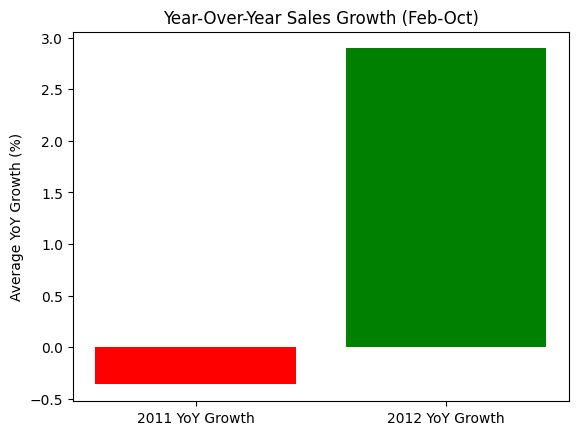

In [53]:
import matplotlib.pyplot as plt
# Calculate YoY growth for each store
df_yearly_pivot = df_yearly.pivot(index='store', columns='year', values='total_sales')
df_yearly_pivot['growth_2011'] = (df_yearly_pivot[2011.0] - df_yearly_pivot[2010.0]) / df_yearly_pivot[2010.0] * 100
df_yearly_pivot['growth_2012'] = (df_yearly_pivot[2012.0] - df_yearly_pivot[2011.0]) / df_yearly_pivot[2011.0] * 100

# Plot average YoY growth across stores
avg_growth = df_yearly_pivot[['growth_2011', 'growth_2012']].mean()
print(avg_growth)
plt.bar(['2011 YoY Growth', '2012 YoY Growth'], avg_growth, color=['red', 'green'])
plt.ylabel('Average YoY Growth (%)')
plt.title('Year-Over-Year Sales Growth (Feb-Oct)')
plt.show()

### Per-Store Year-Over-Year Growth

<Axes: title={'center': 'Year-Over-Year Sales Growth by Store (Feb-Oct)'}, xlabel='Store', ylabel='YoY Growth (%)'>

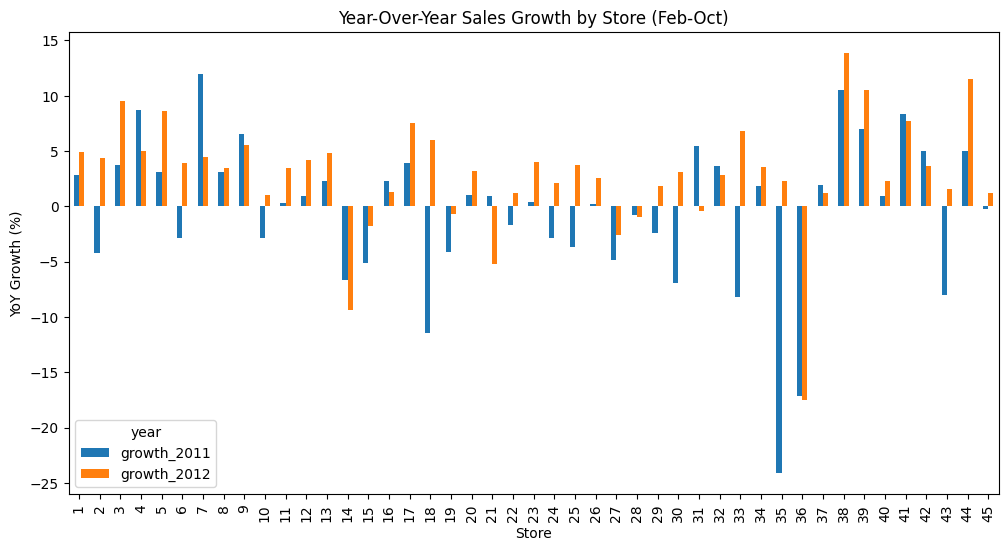

In [47]:
df_yearly_pivot[['growth_2011', 'growth_2012']].plot(
    kind='bar', 
    figsize=(12, 6), 
    title='Year-Over-Year Sales Growth by Store (Feb-Oct)', 
    ylabel='YoY Growth (%)', 
    xlabel='Store')

## Do holidays increase sales?

In [6]:
query = """
SELECT 
    holiday_flag, 
    AVG(weekly_sales) AS avg_weekly_sales
FROM sales
GROUP BY  holiday_flag
ORDER BY avg_weekly_sales DESC;
"""
df_result1 = load_sql_with_fallback(query)
print("Query result preview:")
print(df_result1)
print("Average percent increase in holiday sales, holiday vs non-holiday: ", 
      (df_result1.loc[df_result1['holiday_flag'] == 1, 'avg_weekly_sales'].values[0] - df_result1.loc[df_result1['holiday_flag'] == 0, 'avg_weekly_sales'].values[0]) / df_result1.loc[df_result1['holiday_flag'] == 0, 'avg_weekly_sales'].values[0] * 100, "%")

Query result preview:
   holiday_flag  avg_weekly_sales
0          True      1.122888e+06
1         False      1.041256e+06
Average percent increase in holiday sales, holiday vs non-holiday:  7.839713033050179 %


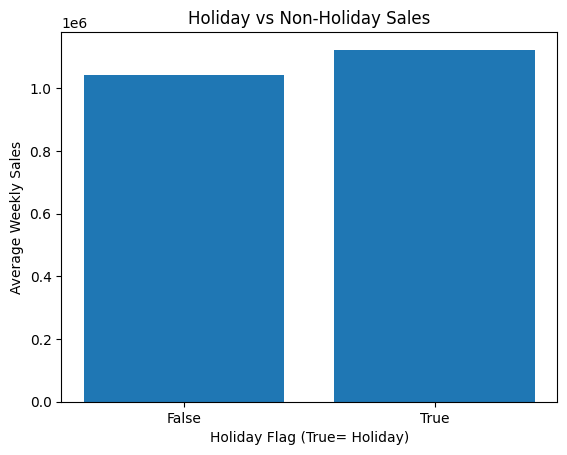

In [ ]:
import matplotlib.pyplot as plt
# Group by holiday_flag and get the avg sales for plotting
avg_sales = df_result1.groupby('holiday_flag')['avg_weekly_sales'].mean()
# Reindex to enforce order
avg_sales = avg_sales.reindex([False, True])

# Plot
plt.bar(avg_sales.index.astype(str), avg_sales.values, color = ['red', 'green'])
plt.xlabel("Holiday Flag (True= Holiday)")
plt.ylabel("Average Weekly Sales")
plt.title("Holiday vs Non-Holiday Sales")
plt.show()

#### Does Christmas increase sales further?
Since 'holiday_flag' includes multiple holidays, we will analyze the average sales for Christmas weeks vs non-holiday weeks to determine the overall impact of Christmas, one of the busiest days for businesses, on sales.

In [8]:
df = df_full.copy()
df['is_christmas_week'] = df['date'].apply(lambda x: x.month == 12 and 19 <= x.day <= 25)
grouped = df.groupby('is_christmas_week')['weekly_sales'].mean()
print(f"Average weekly sales during Christmas week: {grouped[True]:.2f}")
print(f"Average weekly sales during non-Christmas weeks: {grouped[False]:.2f}")
print(f"Percent increase in sales during Christmas week: {(grouped[True] - grouped[False]) / grouped[False] * 100:.2f}%")

Average weekly sales during Christmas week: 1754773.97
Average weekly sales during non-Christmas weeks: 1036925.03
Percent increase in sales during Christmas week: 69.23%


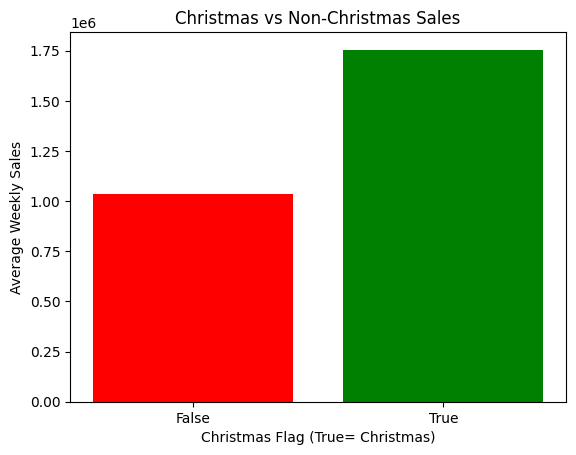

In [68]:
import matplotlib.pyplot as plt

plt.bar(grouped.index.astype(str), grouped.values, color=['red', 'green'])
plt.xlabel("Christmas Flag (True= Christmas)")
plt.ylabel("Average Weekly Sales")
plt.title("Christmas vs Non-Christmas Sales")
plt.show()

#### Does the effect vary by store?

In [10]:
query = """
SELECT 
    store, 
    AVG(CASE WHEN holiday_flag THEN weekly_sales END) AS avg_holiday_sales,
    AVG(CASE WHEN NOT holiday_flag THEN weekly_sales END) AS avg_non_holiday_sales,
    AVG(CASE WHEN holiday_flag THEN weekly_sales END) - AVG(CASE WHEN NOT holiday_flag THEN weekly_sales END) AS sales_diff
FROM sales
GROUP BY store
ORDER BY sales_diff DESC;
"""
df_result = load_sql_with_fallback(query)
# print("Query result preview:")
# print(df_result)

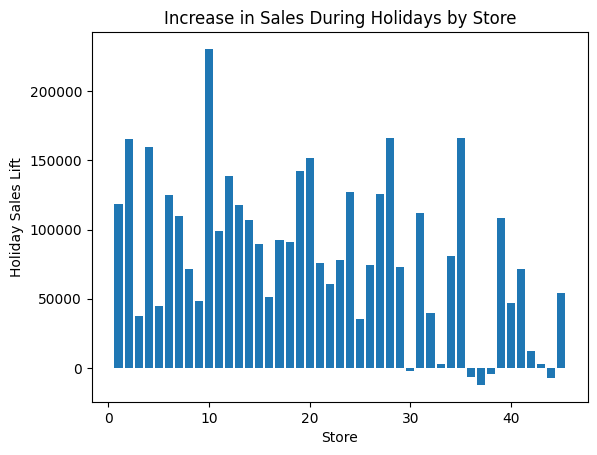

In [11]:
plt.bar(df_result['store'], df_result['sales_diff'])
plt.xlabel("Store")
plt.ylabel("Holiday Sales Lift")
plt.title("Increase in Sales During Holidays by Store")
plt.show()

Some stores have very high differences between holiday-week sales and non-holiday-week sales, but almost all stores have an increase in sales on holidays. 

## Which stores generate the most sales?

In [12]:
query = """
SELECT 
    store, 
    SUM(weekly_sales) AS total_weekly_sales
FROM sales
GROUP BY store
ORDER BY total_weekly_sales DESC;
"""
df_result3 = load_sql_with_fallback(query)
print("Query result preview:")
print(df_result3.head())
print(f"Percentage of sales from top 5 stores: {df_result3[df_result3['store'].isin([20, 4, 14, 13, 2])]["total_weekly_sales"].sum() / df_result3["total_weekly_sales"].sum():.2f}%")

Query result preview:
   store  total_weekly_sales
0     20        3.013978e+08
1      4        2.995440e+08
2     14        2.889999e+08
3     13        2.865177e+08
4      2        2.753824e+08
Percentage of sales from top 5 stores: 0.22%


Stores 20, 4, 14, 13, and 2 combined make up 22% of total sales during this time period.

## Do factors such as temperature, fuel price, or consumer price index (CPI) correlate with weekly sales?

In [13]:
query = """
SELECT 
    CORR(weekly_sales, temperature) AS temp_corr,
    CORR(weekly_sales, fuel_price) AS fuel_corr,
    CORR(weekly_sales, unemployment) AS unemployment_corr,
    CORR(weekly_sales, cpi) AS cpi_corr
FROM sales;
"""
df_result4 = load_sql_with_fallback(query)
print("Query result preview:")
print(df_result4.head())

Query result preview:
   temp_corr  fuel_corr  unemployment_corr  cpi_corr
0   -0.06381   0.009483          -0.106176 -0.072634


Overall, since the correlation coefficients are near 0, temperature, fuel price, and consumer price index shows weak linear correlation on weekly sales.  
However, perhaps it depends on the store.

In [14]:
# query = """
# SELECT 
#     store, 
#     CORR(weekly_sales, temperature) AS temp_corr,
#     CORR(weekly_sales, fuel_price) AS fuel_corr,
#     CORR(weekly_sales, unemployment) AS unemployment_corr,
#     CORR(weekly_sales, cpi) AS cpi_corr
# FROM sales
# GROUP BY store;
# """
# df_result5 = load_sql_with_fallback(query)
# print("Query result preview:")
# print(df_result5.head())

In [15]:
# import math
# df = df_result5  # your query result
# factors = ['Temp', 'Fuel', 'Unemployment', 'CPI']

# num_stores = len(df)
# cols = 5  # number of charts per row
# rows = math.ceil(num_stores / cols)

# fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 5*rows), sharey=True)
# axes = axes.flatten()  # flatten in case rows*cols > num_stores

# for ax, (_, row) in zip(axes, df.iterrows()):
#     values = [row['temp_corr'], row['fuel_corr'], row['unemployment_corr'], row['cpi_corr']]
#     ax.barh(factors, values, color=['skyblue', 'orange', 'green', 'red'])
#     ax.set_xlim(-1, 1)
#     ax.set_title(f'Store {row["store"]}')

# # Hide any extra axes if num_stores < rows*cols
# for ax in axes[num_stores:]:
#     ax.axis('off')

# fig.suptitle('Correlation of Factors with Weekly Sales per Store', fontsize=16)
# fig.tight_layout(rect=[0, 0, 1, 0.95])
# plt.show()

From analysis store-level correlations between weekly sales and temperature, unemployment, fuel, and CPI, some stores have stronger correlations between weekly sales and these external factors. This can be useful when training a predictive or forecasting model on sales, and can guide inventory management with the predicted number of weekly sales using these external factors as a predictive indicator.

## Which stores are more consistent vs more volatile?

In [16]:
# query = """
# SELECT 
#     store,
#     STDDEV(weekly_sales) AS sales_stddev
# FROM sales
# GROUP BY store
# ORDER BY sales_stddev DESC;
# """
# df_result6 = load_sql_with_fallback(query)
# # print("Most volatile stores:")
# # print(df_result6.head())#Most volatile stores based on standard deviation of weekly sales
# # print("Least volatile stores:")
# # print(df_result6.tail())#Least volatile stores based on standard deviation of weekly sales

In [17]:
# # Sort by volatility
# df_sorted = df_result6.sort_values('sales_stddev', ascending=False)

# # Pick top 5 most volatile and bottom 5 least volatile
# top_5 = df_sorted.head(5)
# bottom_5 = df_sorted.tail(5)

# # Combine for plotting
# df_plot = pd.concat([top_5, bottom_5])

# # Create a horizontal bar chart
# plt.figure(figsize=(5,3))
# plt.barh(df_plot['store'].astype(str), df_plot['sales_stddev'], color=['red']*5 + ['green']*5)
# plt.xlabel('Standard Deviation of Weekly Sales')
# plt.ylabel('Store')
# plt.title('Most and Least Volatile Stores')
# plt.gca().invert_yaxis()  # optional: largest value on top
# plt.show()

According to the standard deviation of the stores' weekly sales data, stores 14, 19, 20, 4, and 13 are the most volatile while stores 5, 44, 33, 30, and 37 are the least volatile. However, measuring variation by just standard deviation may be misleading since smaller stores that sell less on average would a less magnitude of variation. Thus, a more useful metric is the coefficient of variation (CV), defined as the standard deviation divided by the mean.

In [18]:
query = """
SELECT 
    store,
    STDDEV(weekly_sales) / AVG(weekly_sales) AS sales_cv
FROM sales
GROUP BY store
ORDER BY sales_CV DESC;
""" 
df_result7 = load_sql_with_fallback(query)

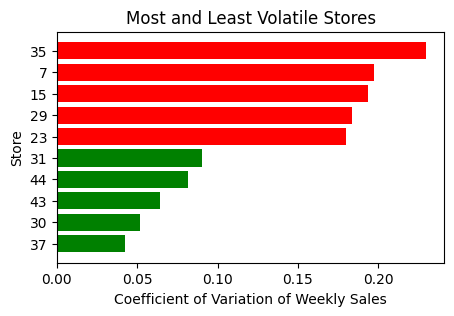

In [19]:
# Sort by CV
df_sorted = df_result7.sort_values('sales_cv', ascending=False)

# Pick top 5 most volatile and bottom 5 least volatile
top_5 = df_sorted.head(5)
bottom_5 = df_sorted.tail(5)

# Combine for plotting
df_plot = pd.concat([top_5, bottom_5])

# Create a horizontal bar chart
plt.figure(figsize=(5,3))
plt.barh(df_plot['store'].astype(str), df_plot['sales_cv'], color=['red']*5 + ['green']*5)
plt.xlabel('Coefficient of Variation of Weekly Sales')
plt.ylabel('Store')
plt.title('Most and Least Volatile Stores')
plt.gca().invert_yaxis()  # optional: largest value on top
plt.show()

According to the coefficient of variability (CV), a measure of relative volatility, the most volatile stores are stores 35, 7, 15, 29, and 23 (different from before). The least volatile stores are stores 31, 44, 43, 30, and 37 (44, 30, and 37 were the least volatile according to standard deviation as well). Variance is an important factor in forecasting sales and deciding inventory and staffing since more variability makes it harder to make predictions on weekly sales or future growth and requires a more flexible inventory. More variance also introduces more risk into the business since it is harder to predict sales and manage inventory, and thus more likely to have overstock or understock.

## Trends in sales over time

In [20]:
query = """
SELECT 
    date,
    SUM(weekly_sales) AS total_sales
FROM sales
GROUP BY date
ORDER BY date;
"""
df_result8 = load_sql_with_fallback(query)

#### Running average to smooth out data

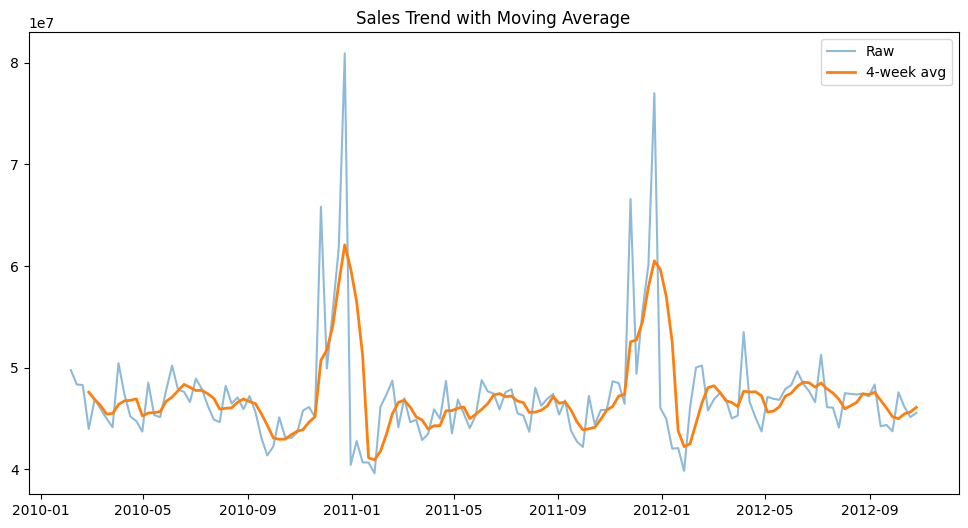

In [21]:
df_result8['rolling_avg'] = df_result8['total_sales'].rolling(window=4).mean()

plt.figure(figsize=(12,6))
plt.plot(df_result8['date'], df_result8['total_sales'], alpha=0.5, label='Raw')
plt.plot(df_result8['date'], df_result8['rolling_avg'], linewidth=2, label='4-week avg')
plt.legend()
plt.title('Sales Trend with Moving Average')
plt.show()

In [22]:
df_result8_sorted = df_result8.sort_values('total_sales', ascending=False)
df_result8_sorted.head(10)

,date,total_sales,rolling_avg
46,2010-12-24,80931415.60,6.208200e+07
98,2011-12-23,76998241.31,6.050891e+07
94,2011-11-25,66593605.26,5.254059e+07
42,2010-11-26,65821003.24,5.071334e+07
45,2010-12-17,61820799.85,5.830440e+07
97,2011-12-16,60085695.94,5.790775e+07
44,2010-12-10,55666770.39,5.413060e+07
96,2011-12-09,55561147.70,5.449607e+07
113,2012-04-06,53502315.87,4.766762e+07
126,2012-07-06,51253021.88,4.848263e+07


In [23]:
df_result8_sorted.tail(10).sort_values('total_sales', ascending=True).head(10)

,date,total_sales,rolling_avg
51,2011-01-28,39599852.99,4.092599e+07
103,2012-01-27,39834974.67,4.222362e+07
47,2010-12-31,40432519.00,5.971288e+07
50,2011-01-21,40654648.03,4.113416e+07
49,2011-01-14,40673678.04,5.120335e+07
33,2010-09-24,41358514.41,4.431697e+07
101,2012-01-13,42023078.48,5.250480e+07
102,2012-01-20,42080996.56,4.377549e+07
86,2011-09-30,42195830.81,4.386778e+07
34,2010-10-01,42239875.87,4.307838e+07


From the graph above, we can see there are some consistent trends over time. There are some peaks in sales around the end of the year, which are likely due to the holiday season around Christmas and Black Friday. The lowest periods of sales are around mid-January to mid-February, which is after the holiday season and before the spring season. There are also some peaks in sales around the end of the summer, which may be due to back-to-school shopping. Overall, there is a clear seasonal pattern in sales, with peaks during the holiday season and back-to-school season, and lower sales during the early part of the year.

#### Monthly sales trends

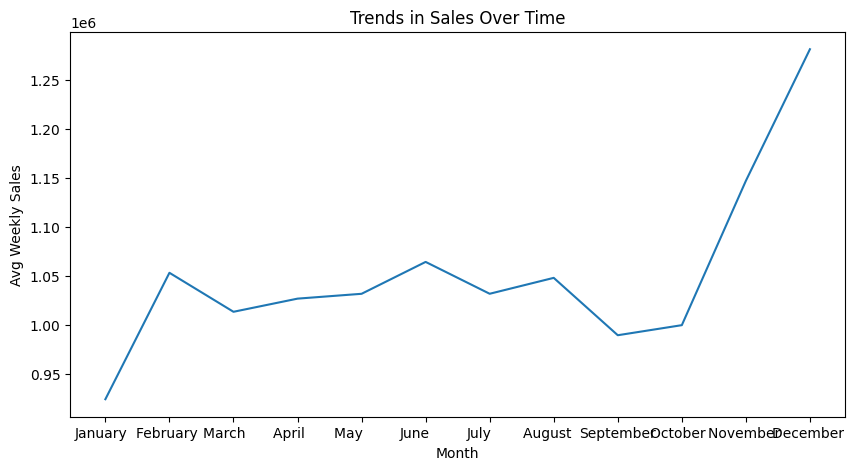

In [24]:
query = """
SELECT
    EXTRACT (MONTH FROM date) AS month,
    TO_CHAR(date, 'Month') AS month_name,
    AVG(weekly_sales) AS avg_sales
FROM sales
GROUP BY month_name, month
ORDER BY month;
"""
df_result9 = load_sql_with_fallback(query)
plt.figure(figsize=(10,5))
plt.plot(df_result9['month_name'], df_result9['avg_sales'])
plt.xlabel('Month')
plt.ylabel('Avg Weekly Sales')
plt.title('Trends in Sales Over Time')
plt.show()

#### Trends in sales over time by store

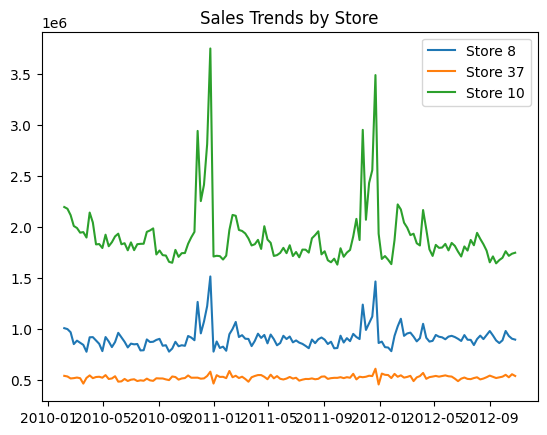

In [25]:
query = """
SELECT 
    store, 
    date,
    weekly_sales
FROM sales
ORDER BY date;
"""
df_result10 = load_sql_with_fallback(query)
df = df_result10.copy()
for store_id in df['store'].unique()[:3]:  # just 3 stores
    subset = df[df['store'] == store_id]
    subset['date'] = pd.to_datetime(subset['date'], dayfirst=True)
    
    plt.plot(subset['date'], subset['weekly_sales'], label=f'Store {store_id}')

plt.legend()
plt.title('Sales Trends by Store')
plt.show()

We can see that the sales trends also varies by store but follows a similar patterns with similar peaks during holiday seasons. Some stores have more pronounced peaks than others, which could be due to the location of the store and how much it is affected by the holiday season. For example, stores in more urban areas may have more pronounced peaks during the holiday season compared to stores in more rural areas.

### Business Recommendations
• Increase inventory and staffing during holiday periods due to consistent sales spikes  
• Focus on high-performing stores for revenue growth strategies  
• Apply flexible inventory planning for high-volatility stores  
• Use store-specific strategies instead of relying solely on macroeconomic indicators or overall trends, since some stores have stronger correlations with external factors than others.